In [11]:
import numpy as np
import pandas as pd
from src.features import cycle
from src._catboost import search_params_mult
from src.MultiVariateForecaster import MultiVariateForecaster
from src.visualization import plot_forecast_with_train
from skforecast.direct import ForecasterDirectMultiVariate
from sklearn.metrics import root_mean_squared_error
import joblib
from catboost import CatBoostRegressor
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

In [12]:
def process_data(data: pd.DataFrame):
    df = data.copy()
    df = df.asfreq('D')
    
    df['day_of_year'] = df['Дата'].dt.dayofyear
    df = cycle(df, 'Месяц', 12)
    df = cycle(df, 'day_of_year', 365)
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)
    
    return df

def fit_best_model(df_train, best_params, target_cols, exog_cols):
    catboost_params = {
        'iterations': best_params['iterations'],
        'learning_rate': best_params['learning_rate'],
        'depth': best_params['depth'],
        'l2_leaf_reg': best_params['l2_leaf_reg'],
        'bootstrap_type': 'Bernoulli',
        'subsample': best_params['subsample'],
        'colsample_bylevel': best_params['colsample_bylevel'],
        'min_data_in_leaf': best_params['min_data_in_leaf'],
        'random_strength': best_params['random_strength'],
        'random_state': 42,
        'verbose': False,
        'thread_count': -1
    }
    
    models = []
    col = target_cols[0]
    lags_dict = {c: None for c in target_cols}
    lags_dict[col] = best_params[f'lags_{col}']
    models.append(ForecasterDirectMultiVariate(estimator=CatBoostRegressor(**catboost_params),
                                                level = col,
                                                steps = 1,
                                                lags = lags_dict))
    
    for i in range(1, len(target_cols)):
        col = target_cols[i]
        neighbor_col = target_cols[i - 1]
        lags_dict = {c: None for c in target_cols}
        lags_dict[col] = best_params[f'lags_{col}']
        lags_dict[neighbor_col] = best_params[f'neighbor_lags_{col}']
        models.append(ForecasterDirectMultiVariate(estimator=CatBoostRegressor(**catboost_params),
                                                level = col,
                                                steps = 1,
                                                lags = lags_dict))
        
        
    forecaster = MultiVariateForecaster(models)
    forecaster.fit(df_train[target_cols], exog=df_train[exog_cols])
    
    return forecaster

In [13]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [14]:
df_train_full = process_data(df_train_full)
df_train = process_data(df_train)
df_val = process_data(df_val)
df_test = process_data(df_test)

In [15]:
model_path = f'../catboost/models/catboost_v2_1'
target_cols = ['48-1 (0)', '48-1 (3)', '48-1 (5)', '48-1 (7)', '48-1 (10)']
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [16]:
study = search_params_mult(df_train, df_val, target_cols, exog_cols=exog_cols, n_trials=10)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-17 19:21:04,353] A new study created in memory with name: no-name-20d006a9-6b96-4674-8bd5-c61cc9abcc34
[I 2026-05-17 19:21:28,380] Trial 0 finished with value: 0.32376158131806776 and parameters: {'iterations': 611, 'learning_rate': 0.29137525682701554, 'depth': 2, 'l2_leaf_reg': 0.008656648409701945, 'subsample': 0.7313724350138806, 'colsample_bylevel': 0.833603923186961, 'min_data_in_leaf': 17, 'random_strength': 4.867629073583289, 'lags_48-1 (0)': 1, 'lags_48-1 (3)': 5, 'neighbor_lags_48-1 (3)': 3, 'lags_48-1 (5)': 5, 'neighbor_lags_48-1 (5)': 2, 'lags_48-1 (7)': 1, 'neighbor_lags_48-1 (7)': 3, 'lags_48-1 (10)': 5, 'neighbor_lags_48-1 (10)': 1}. Best is trial 0 with value: 0.32376158131806776.
[I 2026-05-17 19:21:50,311] Trial 1 finished with value: 0.9787062855859034 and parameters: {'iterations': 346, 'learning_rate': 0.013294162541722073, 'depth': 1, 'l2_leaf_reg': 18.384155446552015, 'subsample': 0.5515073742727556, 'colsample_bylevel': 0.8522812354563971, 'min_data_i

Лучшие параметры = {'iterations': 528, 'learning_rate': 0.05744810493753514, 'depth': 2, 'l2_leaf_reg': 0.0010891573231613173, 'subsample': 0.5305314998035783, 'colsample_bylevel': 0.4012429646583772, 'min_data_in_leaf': 8, 'random_strength': 0.033724714842174305, 'lags_48-1 (0)': 5, 'lags_48-1 (3)': 5, 'neighbor_lags_48-1 (3)': 3, 'lags_48-1 (5)': 4, 'neighbor_lags_48-1 (5)': 3, 'lags_48-1 (7)': 3, 'neighbor_lags_48-1 (7)': 2, 'lags_48-1 (10)': 5, 'neighbor_lags_48-1 (10)': 1}
Лучший RMSE score = 0.31945192353564494


In [17]:
model = fit_best_model(df_train, best_params, target_cols, exog_cols)
joblib.dump(model, model_path)

['../catboost/models/catboost_v2_1']

48-1 (0)
RMSE на тесте = 3.3053382632438106


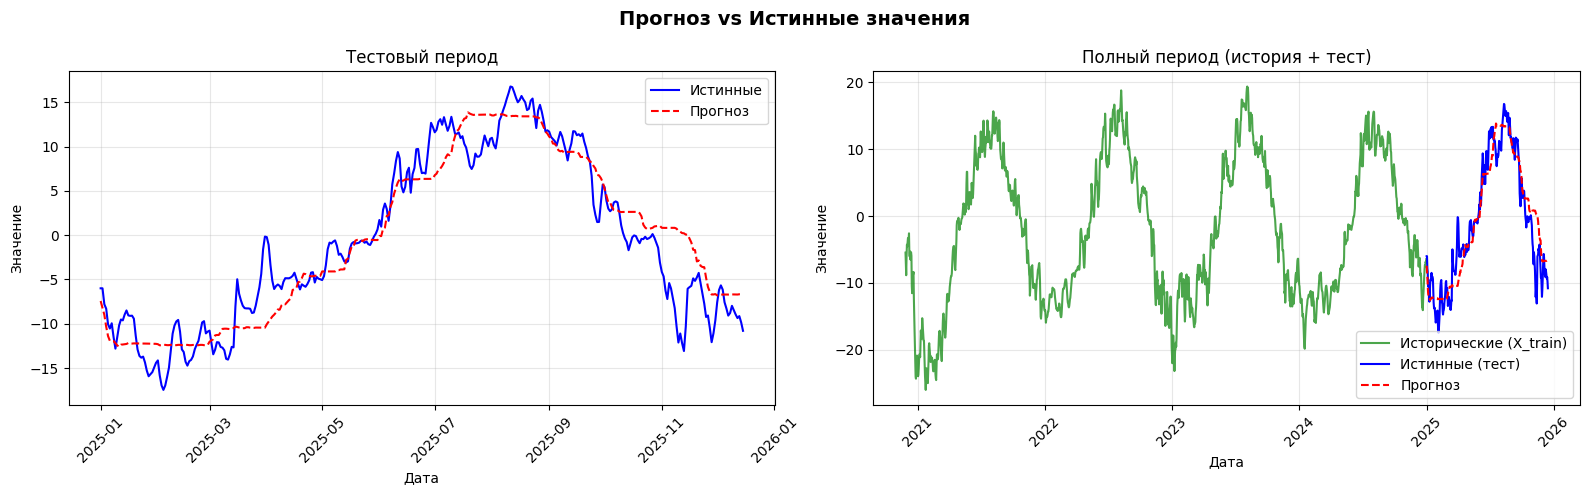

           feature  importance
0   48-1 (0)_lag_1   34.375498
1   48-1 (0)_lag_2   22.596177
3   48-1 (0)_lag_4   16.980637
2   48-1 (0)_lag_3   12.785115
4   48-1 (0)_lag_5    7.291632
6        Месяц_cos    4.703567
8  day_of_year_cos    1.125543
7  day_of_year_sin    0.113109
5        Месяц_sin    0.028722
48-1 (3)
RMSE на тесте = 0.9685549353112998


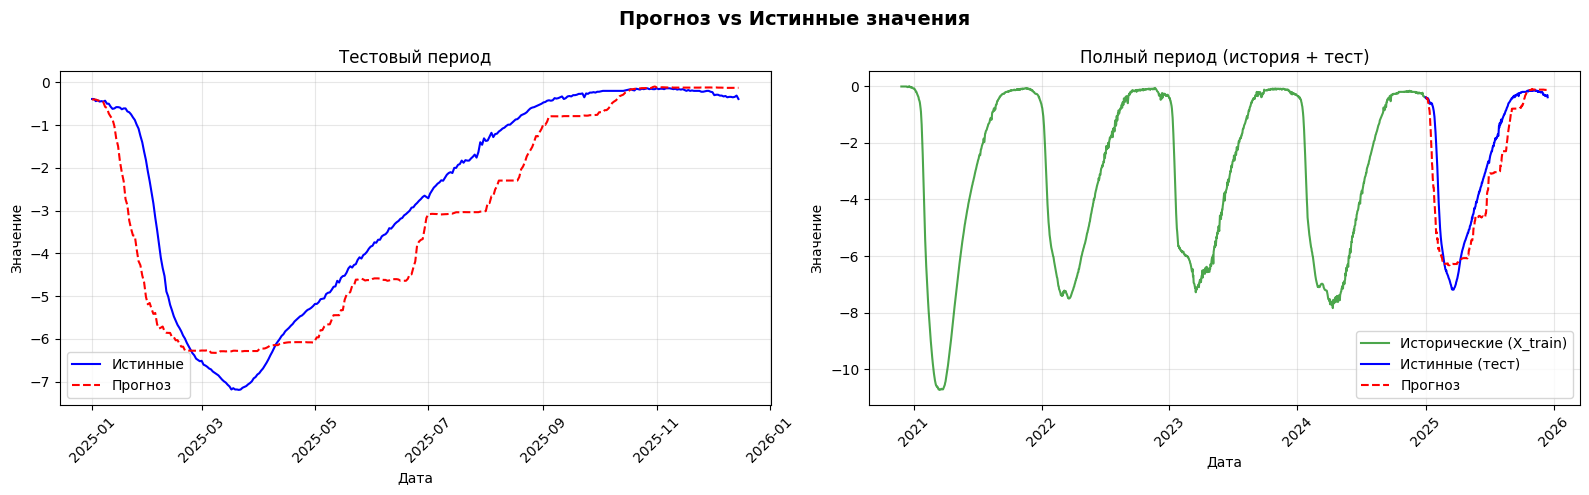

            feature  importance
4    48-1 (3)_lag_2   37.641658
3    48-1 (3)_lag_1   32.346780
5    48-1 (3)_lag_3   19.053335
6    48-1 (3)_lag_4    3.423121
7    48-1 (3)_lag_5    3.155720
10  day_of_year_sin    2.311560
11  day_of_year_cos    1.493306
2    48-1 (0)_lag_3    0.261211
9         Месяц_cos    0.187402
1    48-1 (0)_lag_2    0.059727
8         Месяц_sin    0.045542
0    48-1 (0)_lag_1    0.020637
48-1 (5)
RMSE на тесте = 0.6172769247555675


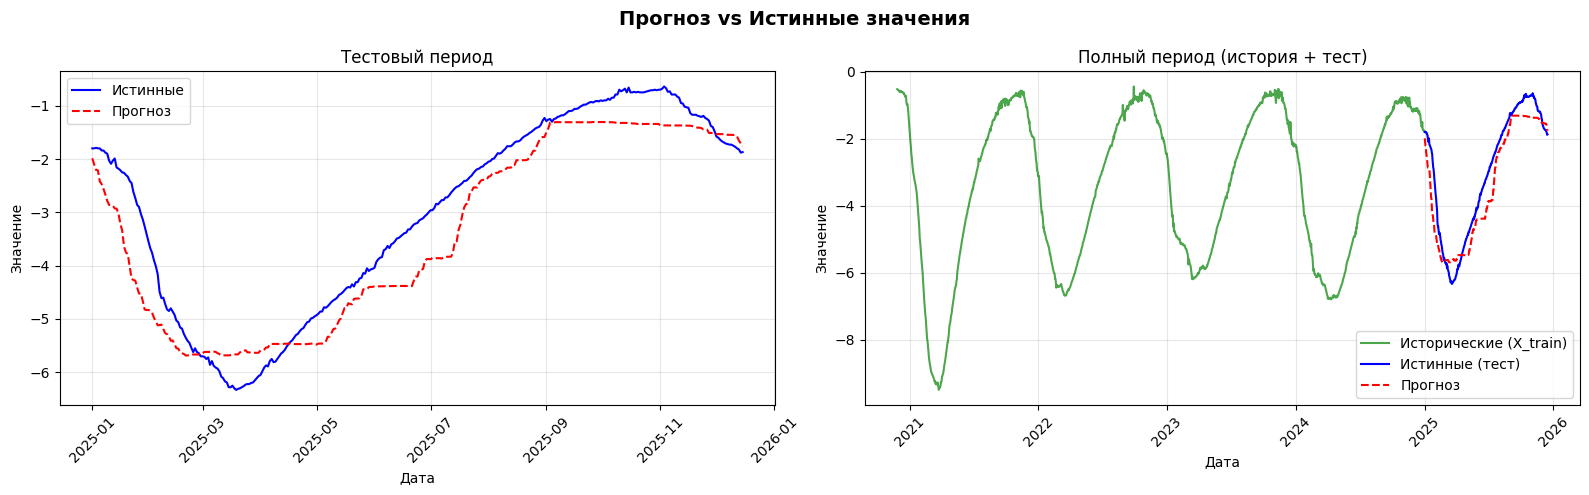

            feature  importance
3    48-1 (5)_lag_1   37.623034
4    48-1 (5)_lag_2   23.229641
5    48-1 (5)_lag_3   10.890120
6    48-1 (5)_lag_4    8.366995
9   day_of_year_sin    8.012030
1    48-1 (3)_lag_2    6.129768
2    48-1 (3)_lag_3    2.062283
0    48-1 (3)_lag_1    1.644046
10  day_of_year_cos    1.255724
7         Месяц_sin    0.751965
8         Месяц_cos    0.034392
48-1 (7)
RMSE на тесте = 0.5078198860782752


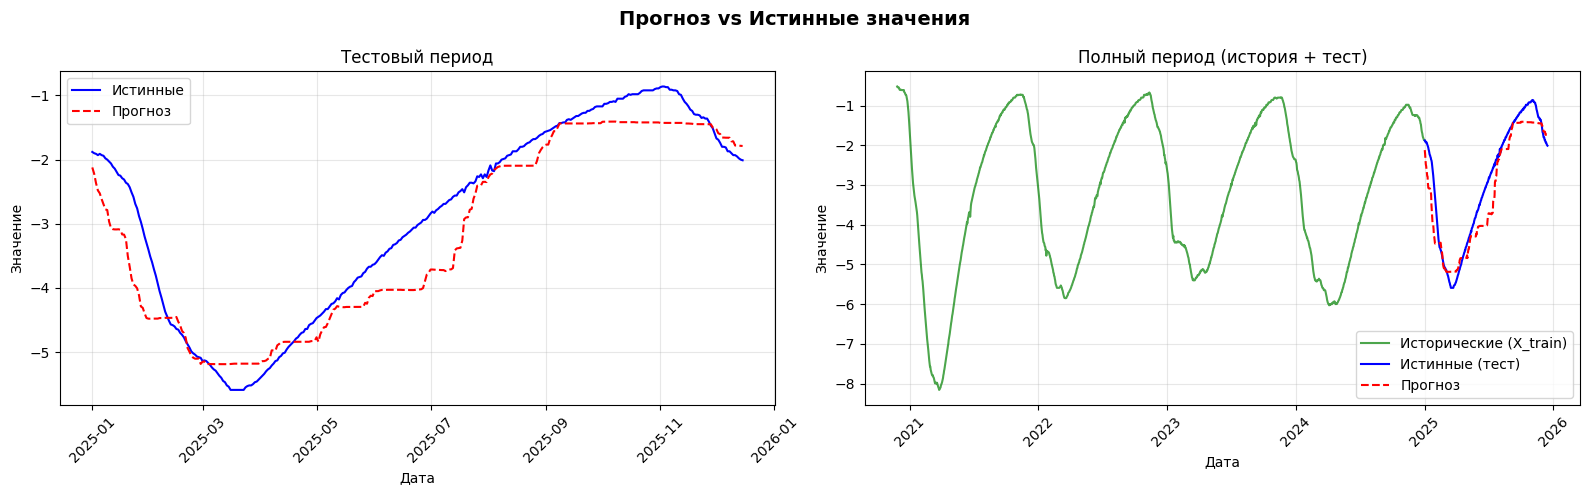

           feature  importance
2   48-1 (7)_lag_1   25.862775
1   48-1 (5)_lag_2   19.606857
0   48-1 (5)_lag_1   18.745133
3   48-1 (7)_lag_2   12.913092
4   48-1 (7)_lag_3   12.324358
5        Месяц_sin    8.611317
6        Месяц_cos    1.199462
7  day_of_year_sin    0.645723
8  day_of_year_cos    0.091284
48-1 (10)
RMSE на тесте = 0.16940745356025502


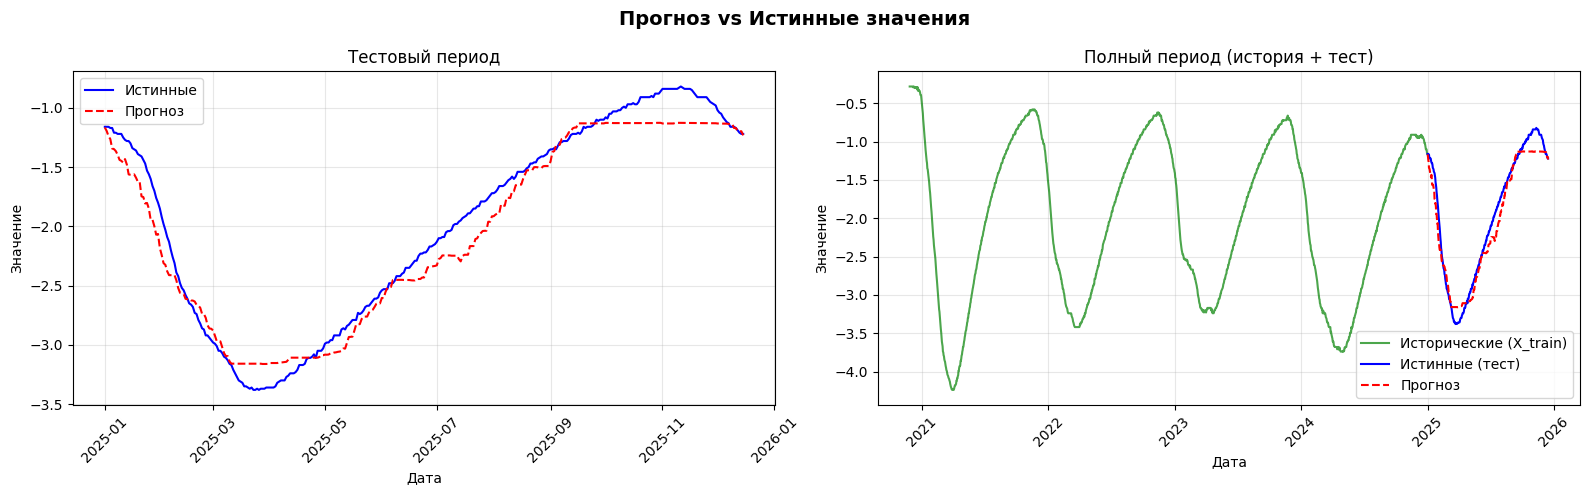

           feature  importance
3  48-1 (10)_lag_3   26.246835
2  48-1 (10)_lag_2   25.240920
1  48-1 (10)_lag_1   14.772333
5  48-1 (10)_lag_5   11.146038
0   48-1 (7)_lag_1   10.430434
4  48-1 (10)_lag_4    6.251337
8  day_of_year_sin    3.739644
7        Месяц_cos    2.064391
9  day_of_year_cos    0.104114
6        Месяц_sin    0.003954


In [18]:
model = joblib.load(model_path)
predicts = model.predict(len(df_test), df_train_full[target_cols], exog=df_test[exog_cols])
for col in target_cols:
    print(col)
    y_pred = predicts[col]
    y_true = df_test[col]
    rmse = root_mean_squared_error(y_true, y_pred)
    print(f'RMSE на тесте = {rmse}')
    
    plot_forecast_with_train(df_train_full[col], y_true, y_pred)
    
    importances = model.forecasters[col].get_feature_importances(step = 1)
    print(importances)

In [23]:
model_path = f'../catboost/models/catboost_v2_2'
target_cols = ['48-Воздух (0)', '48-1 (0)', '48-1 (1)', '48-1 (2)', '48-1 (3)', '48-1 (4)', '48-1 (5)','48-1 (6)', '48-1 (7)', '48-1 (8)', '48-1 (9)', '48-1 (10)', '48-1 (11)']
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [24]:
study = search_params_mult(df_train, df_val, target_cols, exog_cols=exog_cols, n_trials=10)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-17 19:40:42,254] A new study created in memory with name: no-name-6198a8fa-9ea6-4e0f-b00e-bcca1e9e5021
[I 2026-05-17 19:41:53,741] Trial 0 finished with value: 0.3633999781864286 and parameters: {'iterations': 813, 'learning_rate': 0.20137281035341306, 'depth': 6, 'l2_leaf_reg': 25.31616143996086, 'subsample': 0.8362741083323851, 'colsample_bylevel': 0.8313489591194272, 'min_data_in_leaf': 7, 'random_strength': 0.1361180954245247, 'lags_48-Воздух (0)': 4, 'lags_48-1 (0)': 5, 'neighbor_lags_48-1 (0)': 2, 'lags_48-1 (1)': 2, 'neighbor_lags_48-1 (1)': 3, 'lags_48-1 (2)': 4, 'neighbor_lags_48-1 (2)': 2, 'lags_48-1 (3)': 5, 'neighbor_lags_48-1 (3)': 1, 'lags_48-1 (4)': 1, 'neighbor_lags_48-1 (4)': 3, 'lags_48-1 (5)': 2, 'neighbor_lags_48-1 (5)': 1, 'lags_48-1 (6)': 3, 'neighbor_lags_48-1 (6)': 1, 'lags_48-1 (7)': 5, 'neighbor_lags_48-1 (7)': 2, 'lags_48-1 (8)': 1, 'neighbor_lags_48-1 (8)': 2, 'lags_48-1 (9)': 4, 'neighbor_lags_48-1 (9)': 2, 'lags_48-1 (10)': 5, 'neighbor_lags_48-

Лучшие параметры = {'iterations': 310, 'learning_rate': 0.13962103416890723, 'depth': 4, 'l2_leaf_reg': 0.02093526544540552, 'subsample': 0.6771399319591169, 'colsample_bylevel': 0.5795871334801379, 'min_data_in_leaf': 29, 'random_strength': 7.7384331381438844, 'lags_48-Воздух (0)': 1, 'lags_48-1 (0)': 5, 'neighbor_lags_48-1 (0)': 1, 'lags_48-1 (1)': 2, 'neighbor_lags_48-1 (1)': 1, 'lags_48-1 (2)': 2, 'neighbor_lags_48-1 (2)': 2, 'lags_48-1 (3)': 1, 'neighbor_lags_48-1 (3)': 3, 'lags_48-1 (4)': 4, 'neighbor_lags_48-1 (4)': 3, 'lags_48-1 (5)': 3, 'neighbor_lags_48-1 (5)': 1, 'lags_48-1 (6)': 3, 'neighbor_lags_48-1 (6)': 3, 'lags_48-1 (7)': 3, 'neighbor_lags_48-1 (7)': 1, 'lags_48-1 (8)': 5, 'neighbor_lags_48-1 (8)': 3, 'lags_48-1 (9)': 1, 'neighbor_lags_48-1 (9)': 3, 'lags_48-1 (10)': 2, 'neighbor_lags_48-1 (10)': 2, 'lags_48-1 (11)': 3, 'neighbor_lags_48-1 (11)': 3}
Лучший RMSE score = 0.35537215272773726


In [25]:
model = fit_best_model(df_train, best_params, target_cols, exog_cols)
joblib.dump(model, model_path)

['../catboost/models/catboost_v2_2']

48-Воздух (0)
RMSE на тесте = 3.769424384716261


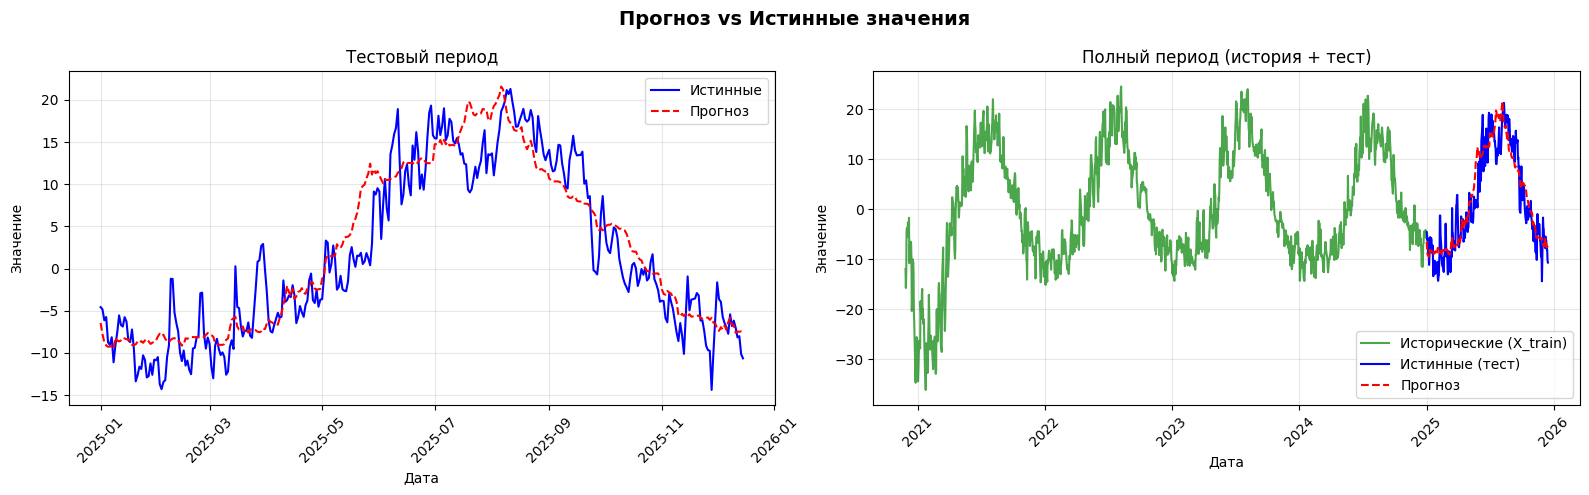

               feature  importance
0  48-Воздух (0)_lag_1   58.401843
4      day_of_year_cos   16.959925
2            Месяц_cos   12.650067
3      day_of_year_sin    7.221185
1            Месяц_sin    4.766979
48-1 (0)
RMSE на тесте = 2.984520630574543


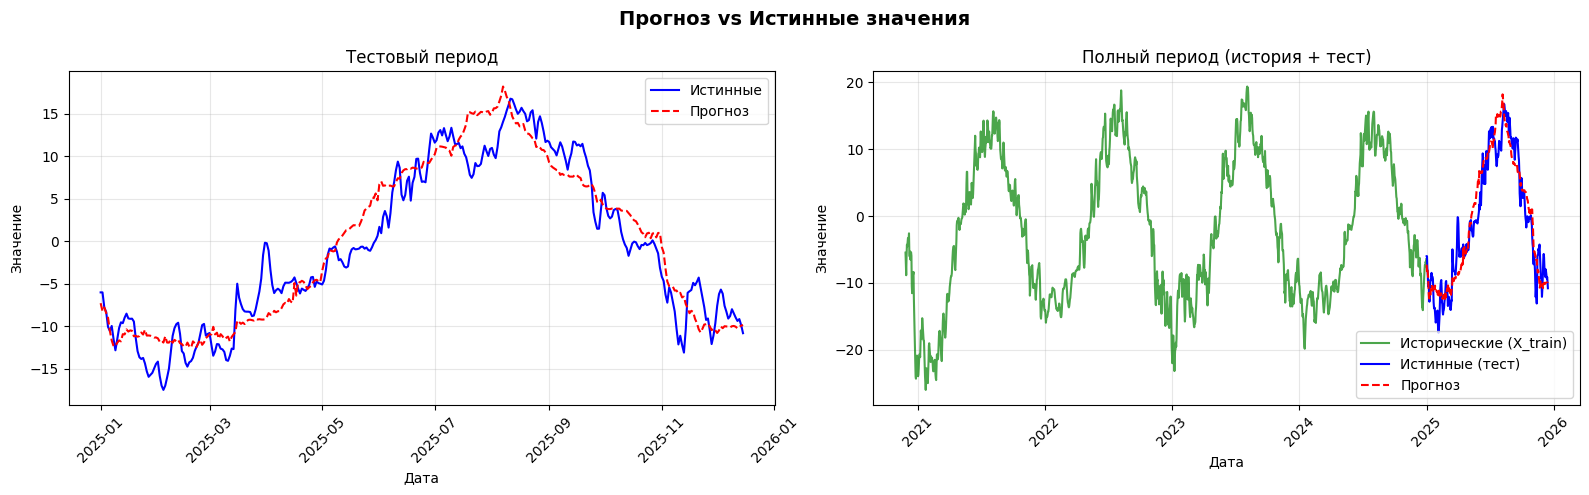

               feature  importance
7            Месяц_cos   25.142069
5       48-1 (0)_lag_5   20.222426
0  48-Воздух (0)_lag_1   12.134058
1       48-1 (0)_lag_1    8.753346
3       48-1 (0)_lag_3    7.536797
2       48-1 (0)_lag_2    6.991004
6            Месяц_sin    6.021648
8      day_of_year_sin    5.664222
4       48-1 (0)_lag_4    4.881907
9      day_of_year_cos    2.652523
48-1 (1)
RMSE на тесте = 1.466317106482477


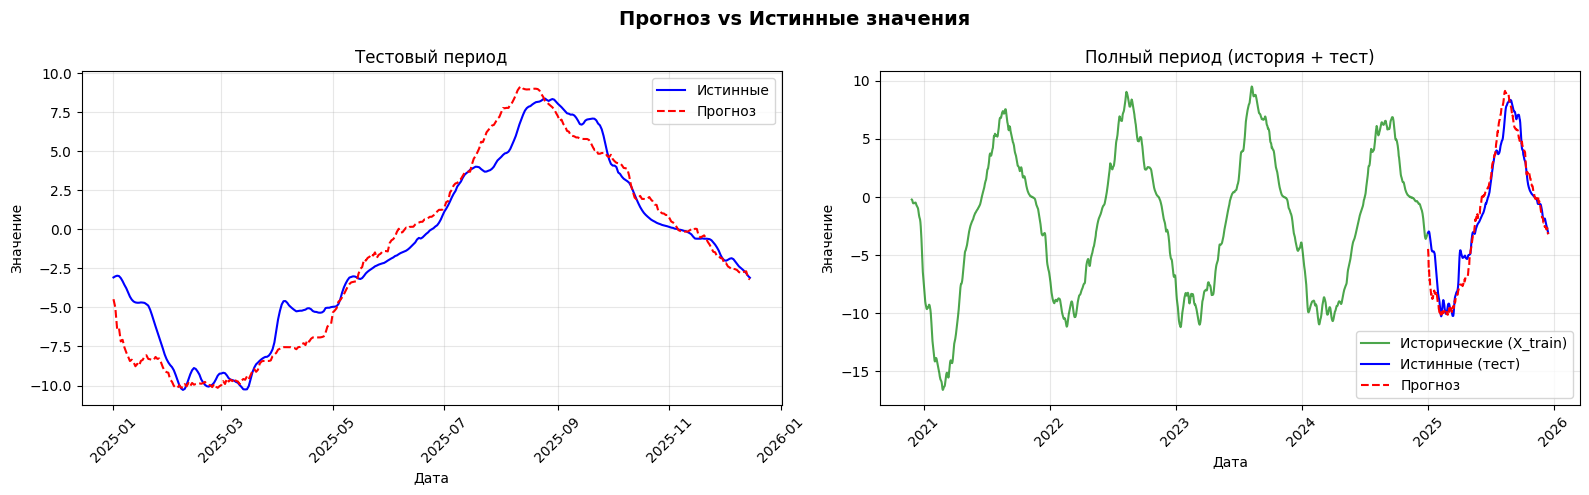

           feature  importance
0   48-1 (0)_lag_1   45.312919
3        Месяц_sin   17.032917
5  day_of_year_sin   12.830306
1   48-1 (1)_lag_1    9.626886
2   48-1 (1)_lag_2    5.982657
4        Месяц_cos    4.773328
6  day_of_year_cos    4.440987
48-1 (2)
RMSE на тесте = 0.8811318168496198


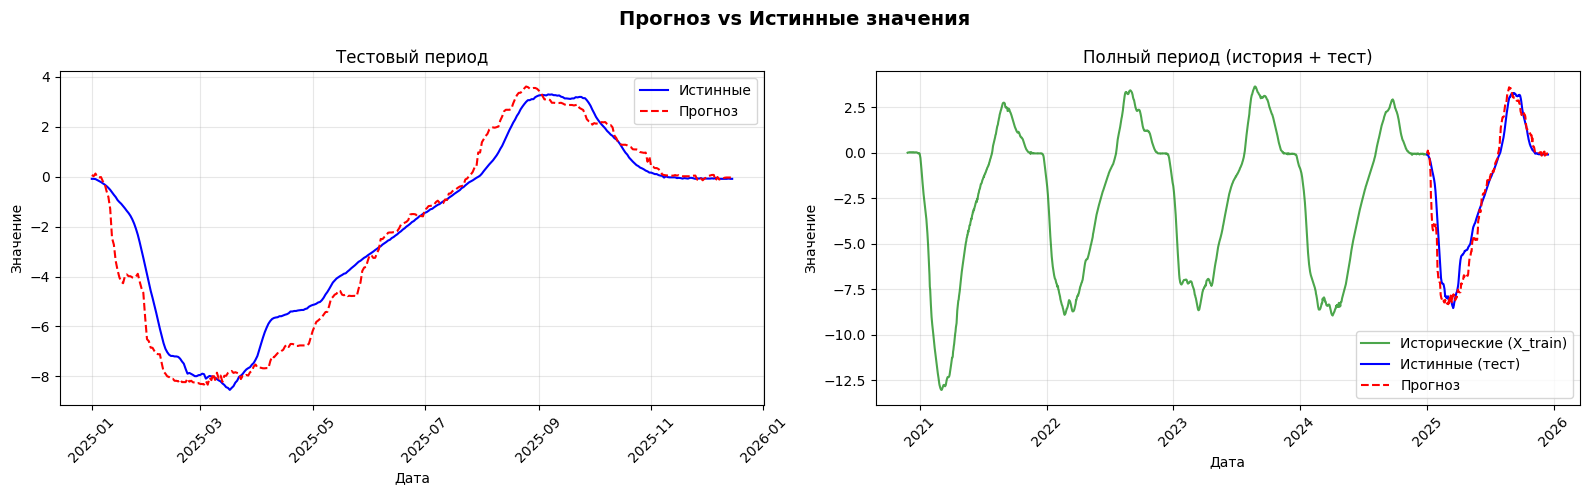

           feature  importance
2   48-1 (2)_lag_1   27.183374
6  day_of_year_sin   23.602075
3   48-1 (2)_lag_2   13.996458
7  day_of_year_cos   10.612856
4        Месяц_sin    9.101830
1   48-1 (1)_lag_2    8.182323
0   48-1 (1)_lag_1    5.020171
5        Месяц_cos    2.300913
48-1 (3)
RMSE на тесте = 0.5752403569284312


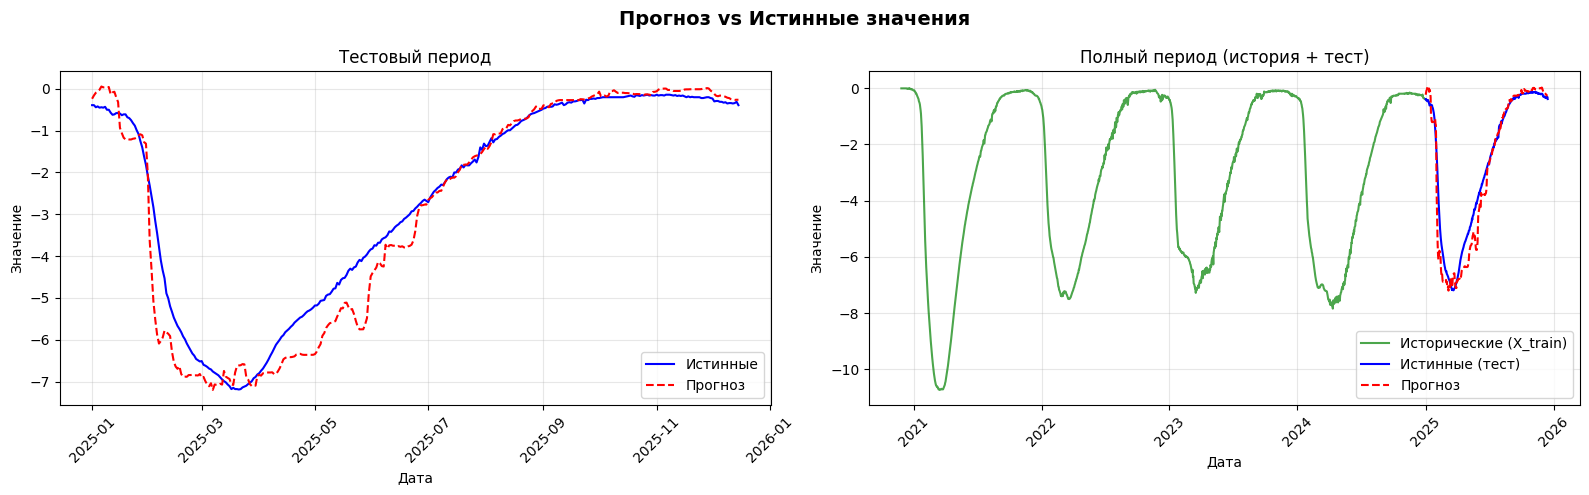

           feature  importance
2   48-1 (2)_lag_3   36.568650
1   48-1 (2)_lag_2   17.930973
3   48-1 (3)_lag_1   17.617768
4        Месяц_sin   11.610628
0   48-1 (2)_lag_1    5.975802
7  day_of_year_cos    4.998055
5        Месяц_cos    2.776257
6  day_of_year_sin    2.521867
48-1 (4)
RMSE на тесте = 0.5100229950508148


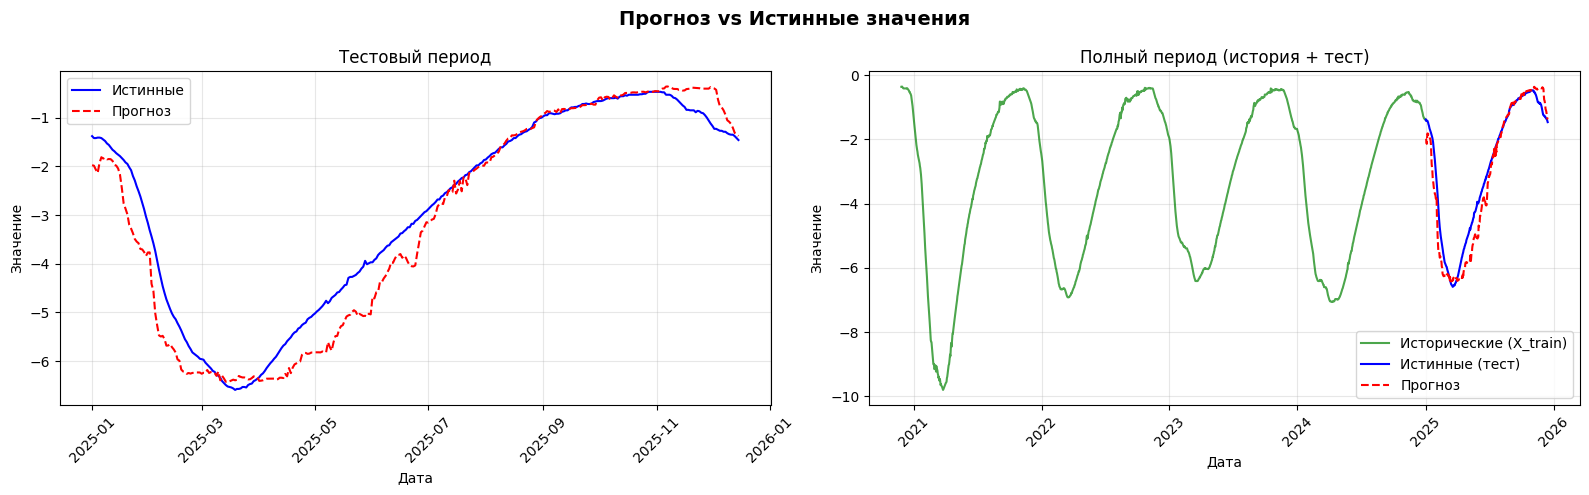

            feature  importance
0    48-1 (3)_lag_1   25.898591
5    48-1 (4)_lag_3   21.041766
2    48-1 (3)_lag_3   18.719829
9   day_of_year_sin    9.197217
1    48-1 (3)_lag_2    7.692152
8         Месяц_cos    4.758707
4    48-1 (4)_lag_2    3.893404
6    48-1 (4)_lag_4    3.151596
10  day_of_year_cos    2.759225
3    48-1 (4)_lag_1    2.170084
7         Месяц_sin    0.717428
48-1 (5)
RMSE на тесте = 0.46965342692509315


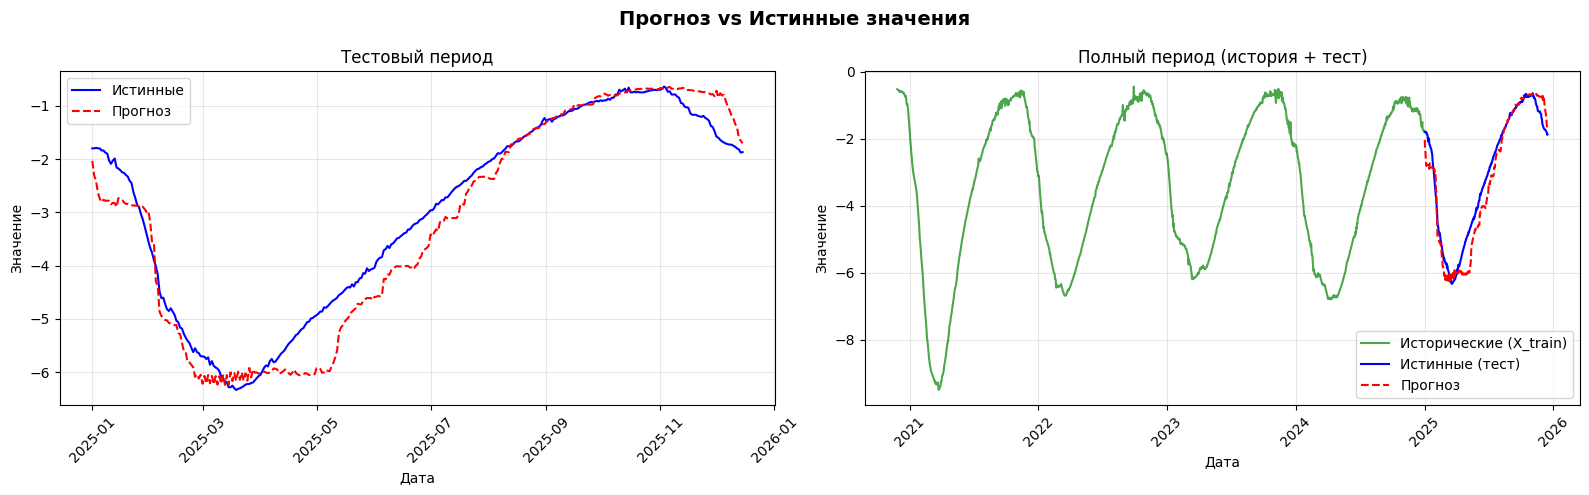

           feature  importance
1   48-1 (5)_lag_1   32.362125
3   48-1 (5)_lag_3   20.627341
2   48-1 (5)_lag_2   16.317836
4        Месяц_sin   13.640183
0   48-1 (4)_lag_1    8.735709
7  day_of_year_cos    4.272281
6  day_of_year_sin    2.343464
5        Месяц_cos    1.701060
48-1 (6)
RMSE на тесте = 0.4186629944004948


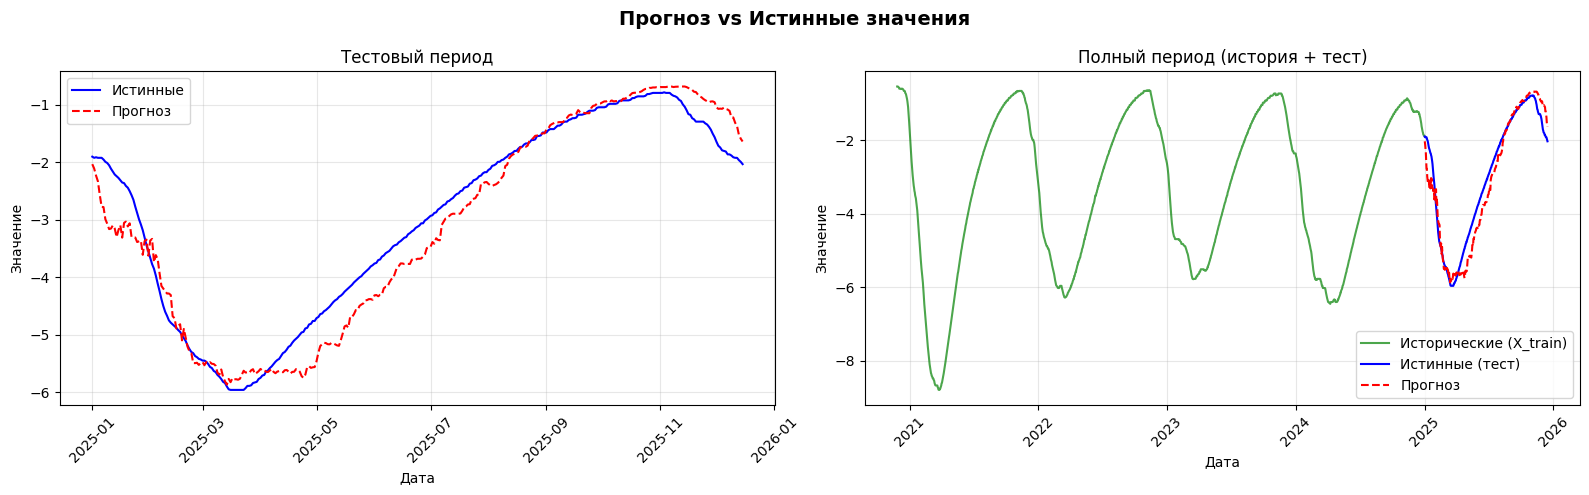

           feature  importance
3   48-1 (6)_lag_1   44.018138
5   48-1 (6)_lag_3   16.471854
1   48-1 (5)_lag_2   14.714410
4   48-1 (6)_lag_2    9.372859
8  day_of_year_sin    3.575097
0   48-1 (5)_lag_1    3.328497
2   48-1 (5)_lag_3    2.996669
7        Месяц_cos    2.125889
6        Месяц_sin    1.930570
9  day_of_year_cos    1.466017
48-1 (7)
RMSE на тесте = 0.4335752096992845


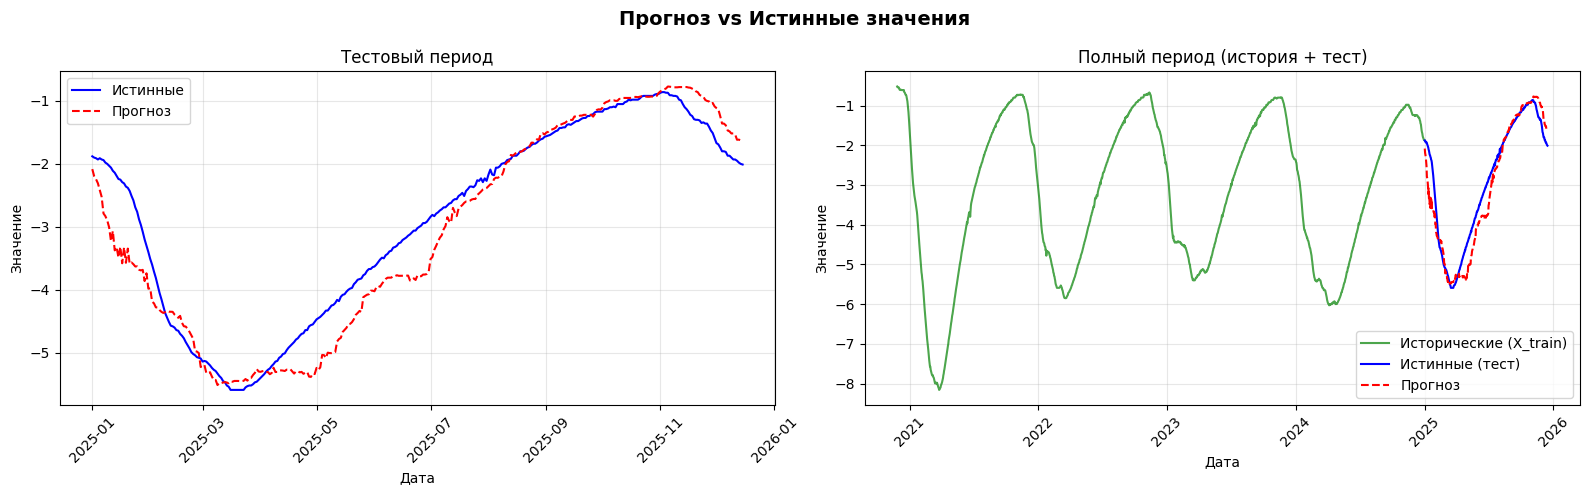

           feature  importance
2   48-1 (7)_lag_2   32.853104
1   48-1 (7)_lag_1   24.046733
3   48-1 (7)_lag_3   17.625952
4        Месяц_sin   10.698849
0   48-1 (6)_lag_1    7.687286
7  day_of_year_cos    3.917590
5        Месяц_cos    1.737995
6  day_of_year_sin    1.432489
48-1 (8)
RMSE на тесте = 0.3709957673811279


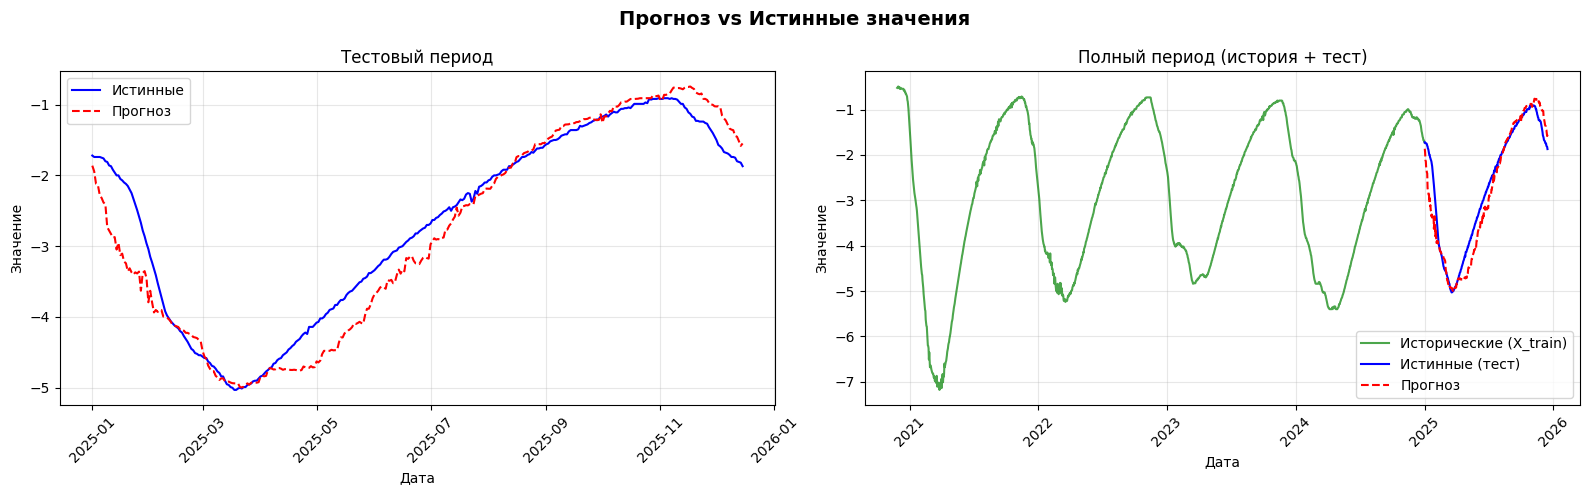

            feature  importance
1    48-1 (7)_lag_2   25.002877
6    48-1 (8)_lag_4   24.238349
3    48-1 (8)_lag_1   10.455268
0    48-1 (7)_lag_1   10.357544
10  day_of_year_sin    6.624479
7    48-1 (8)_lag_5    5.545734
2    48-1 (7)_lag_3    4.597788
9         Месяц_cos    4.000999
8         Месяц_sin    3.912874
4    48-1 (8)_lag_2    2.958140
5    48-1 (8)_lag_3    1.232840
11  day_of_year_cos    1.073108
48-1 (9)
RMSE на тесте = 0.2652451992903136


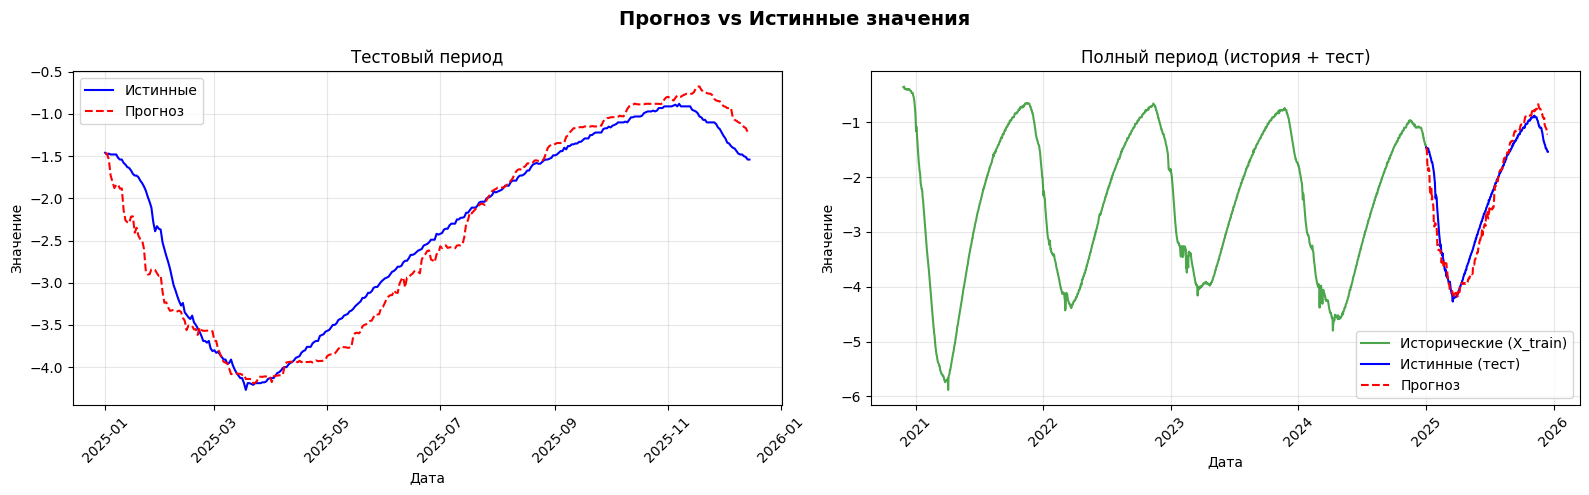

           feature  importance
1   48-1 (8)_lag_2   26.281352
3   48-1 (9)_lag_1   24.946072
2   48-1 (8)_lag_3   16.843446
4        Месяц_sin   12.602604
0   48-1 (8)_lag_1    8.192937
7  day_of_year_cos    6.652575
5        Месяц_cos    2.467488
6  day_of_year_sin    2.013526
48-1 (10)
RMSE на тесте = 0.13972138360362543


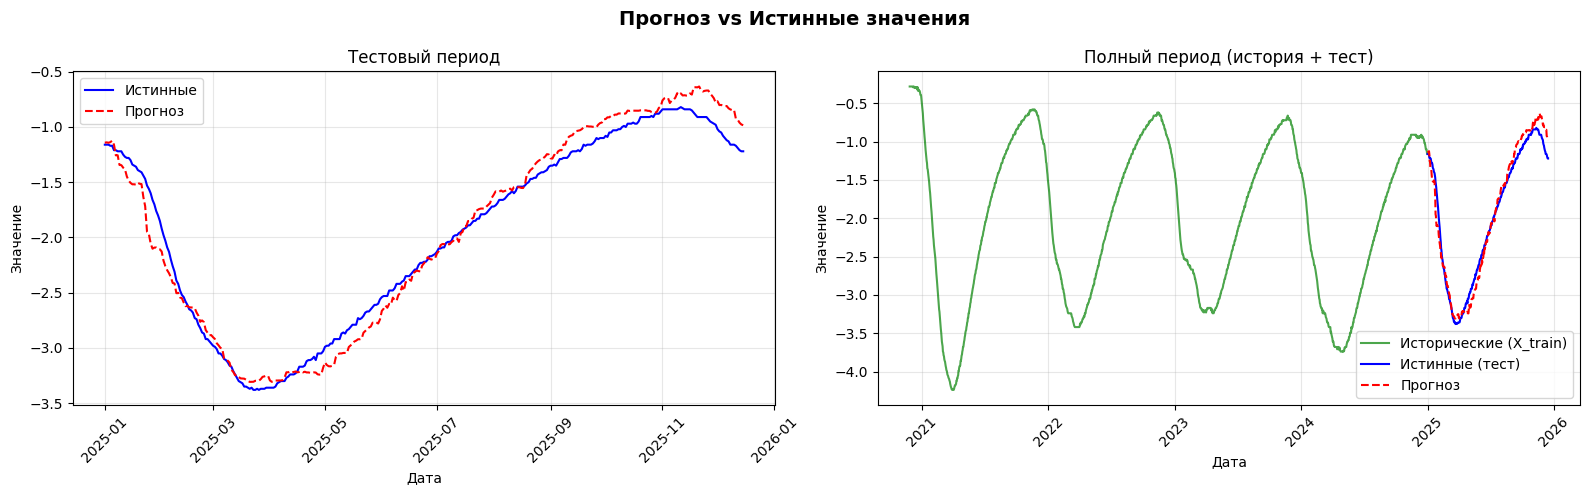

           feature  importance
2  48-1 (10)_lag_1   28.859114
6  day_of_year_sin   20.280864
1   48-1 (9)_lag_2   15.934571
7  day_of_year_cos   10.331952
3  48-1 (10)_lag_2    8.037642
4        Месяц_sin    7.770026
0   48-1 (9)_lag_1    6.899058
5        Месяц_cos    1.886773
48-1 (11)
RMSE на тесте = 0.16417347595923956


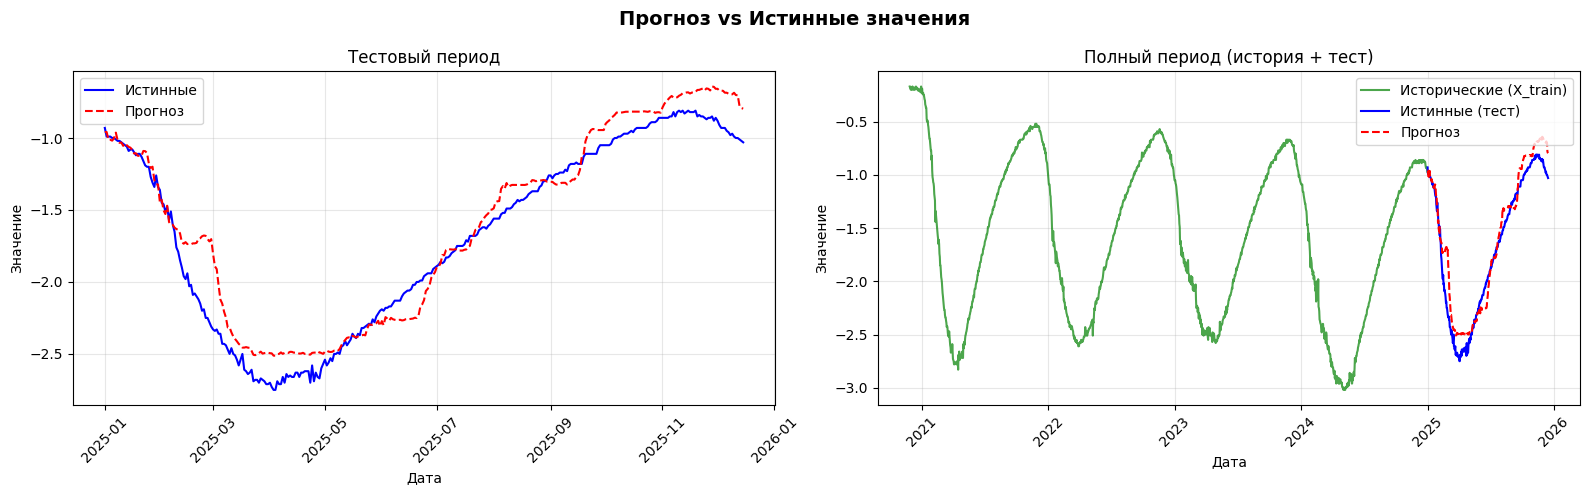

           feature  importance
3  48-1 (11)_lag_1   26.418555
1  48-1 (10)_lag_2   21.263563
5  48-1 (11)_lag_3   17.954864
4  48-1 (11)_lag_2   12.364505
6        Месяц_sin    9.564612
7        Месяц_cos    3.902277
2  48-1 (10)_lag_3    2.765248
9  day_of_year_cos    2.382781
0  48-1 (10)_lag_1    2.012326
8  day_of_year_sin    1.371270


In [26]:
model = joblib.load(model_path)
predicts = model.predict(len(df_test), df_train_full[target_cols], exog=df_test[exog_cols])
for col in target_cols:
    print(col)
    y_pred = predicts[col]
    y_true = df_test[col]
    rmse = root_mean_squared_error(y_true, y_pred)
    print(f'RMSE на тесте = {rmse}')
    
    plot_forecast_with_train(df_train_full[col], y_true, y_pred)
    
    importances = model.forecasters[col].get_feature_importances(step = 1)
    print(importances)